In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox

In [26]:
glass = pd.read_csv('glass.csv')

In [27]:
glass['Type'].value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

## **MODEL**

In [28]:
# Independent & Dependent

X = glass.drop('Type', axis=1)
y = glass['Type']

In [29]:
# Standarisasi

X = (X_before - X_before.mean()) / X_before.std()

In [30]:
# Split Train Test

def split_data(X, y, size=0.8):
    np.random.seed(42)

    x_train, x_test = [], []
    y_train, y_test = [], []
    for class_value in np.unique(y):
        class_idx = np.where(y == class_value)[0]

        idx = np.random.permutation(class_idx)
        split = int(len(idx) * size)

        x_train.append(X.iloc[idx[:split]])
        x_test.append(X.iloc[idx[split:]])
        y_train.append(y.iloc[idx[:split]])
        y_test.append(y.iloc[idx[split:]])

    X_train = pd.concat(x_train).reset_index(drop = True)
    X_test = pd.concat(x_test).reset_index(drop = True)
    y_train = pd.concat(y_train).reset_index(drop = True)
    y_test = pd.concat(y_test).reset_index(drop = True)

    return X_train, X_test, y_train, y_test

In [31]:
# Insisialisasi Fungsi

X_train, X_test, y_train, y_test = split_data(X, y)

In [32]:
# Cek Shape Tiap Variabel

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(169, 9)
(45, 9)
(169,)
(45,)


In [33]:
# Model KNN

class KNN:
    def __init__(self, k, p):
        self.k = k
        self.p = p
    def train(self, X, y):
        self.X_train = X
        self.y_train = y

    def distance(self, x1, x2):
        if self.p == 1:
            return np.sum(np.abs(x1 - x2))
        else:
            return np.sqrt(np.sum((x1 - x2)**2))
    
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
    
    def _predict(self, x):
        distance_i = [self.distance(x, X_train) for X_train in self.X_train]
        best_k = np.argsort(distance_i)[:self.k]
        label_k = [self.y_train[i] for i in best_k]
        result = max(set(label_k), key=label_k.count)
        return result

In [34]:
# Mencari K dan Jarak dengan akurasi terbaik

best_acc = 0
best_k = {}

for k in [3,5,7,9,11]:
    for p in [1,2]:
        model = KNN(k, p)
        model.train(X_train.values, y_train.values)
        pred = model.predict(X_test.values)
        acc = np.mean(pred == y_test.values)

        distance = 'manhattan' if p == 1 else 'euclidean'
        print(f'K: {k} - Distance: {distance} - Accuracy: {acc:.4f}')

        if acc > best_acc:
            best_acc = acc
            best_k = {'k':k, 'p':p}
distance_label = 'manhattan' if p == 1 else 'euclidean'
print(f'Best K: {best_k.get('k', 'N/A')} - Distance: {distance_label} - Accuracy: {best_acc:.4f}')

K: 3 - Distance: manhattan - Accuracy: 0.7556
K: 3 - Distance: euclidean - Accuracy: 0.7778
K: 5 - Distance: manhattan - Accuracy: 0.6889
K: 5 - Distance: euclidean - Accuracy: 0.6889
K: 7 - Distance: manhattan - Accuracy: 0.6667
K: 7 - Distance: euclidean - Accuracy: 0.6667
K: 9 - Distance: manhattan - Accuracy: 0.6667
K: 9 - Distance: euclidean - Accuracy: 0.7111
K: 11 - Distance: manhattan - Accuracy: 0.7111
K: 11 - Distance: euclidean - Accuracy: 0.6444
Best K: 3 - Distance: euclidean - Accuracy: 0.7778


In [35]:
# Inisisalisasi Model Menggunakan K dan Jarak Terbaik

model = KNN(k=best_k.get('k'), p=best_k.get('p'))
model.train(X_train.values, y_train.values)

In [36]:
# Prediksi Train dan Test

y_pred_train = model.predict(X_train.values)
y_pred_test = model.predict(X_test.values)

In [37]:
# Fungsi Evaluasi

def evaluate(y_true, y_pred, title='Train'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    classes = np.unique(y_true)
    n_classes = len(classes)

    accuracy = np.mean(y_true == y_pred)
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    precision = np.mean(precision)
    recall = np.mean(recall)
    f1 = np.mean(f1)

    print(f'Evaluasi {title}')
    print(f'Accuracy    : {accuracy:.4%}')
    print(f'Precision   : {precision:.4%}')
    print(f'Recall      : {recall:.4%}')
    print(f'F1          : {f1:.4%}')

In [38]:
# Inisialisasi Fungsi Evaluasi terhadap Train

evaluate(y_train, y_pred_train, title='Train')

Evaluasi Train
Accuracy    : 82.8402%
Precision   : 83.0075%
Recall      : 73.4427%
F1          : 76.8733%


In [39]:
# Inisialisasi Fungsi Evaluasi terhadap Test

evaluate(y_test, y_pred_test, title='Test')

Evaluasi Test
Accuracy    : 77.7778%
Precision   : 89.1053%
Recall      : 61.7063%
F1          : 67.1303%


## **VISUALISASI**

In [40]:
# Confuion Matrix

def confusion_matrix(y_true, y_pred, title='Train'):
    classes = np.unique(y_true)
    n_classes = len(classes)
    
    cm  = np.zeros((n_classes, n_classes))

    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i,j] = np.sum((y_true == c_true) * (y_pred == c_pred))

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues')
    plt.title(f'Confusion Matrix {title}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

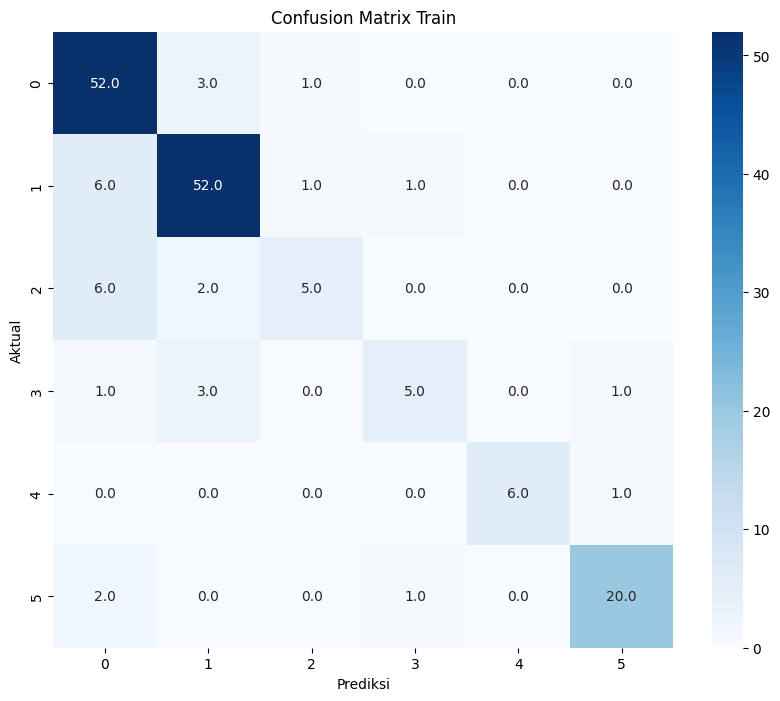

In [41]:
# Inisialisasi Fungsi Confision Matrix terhadap Train

confusion_matrix(y_train, y_pred_train)

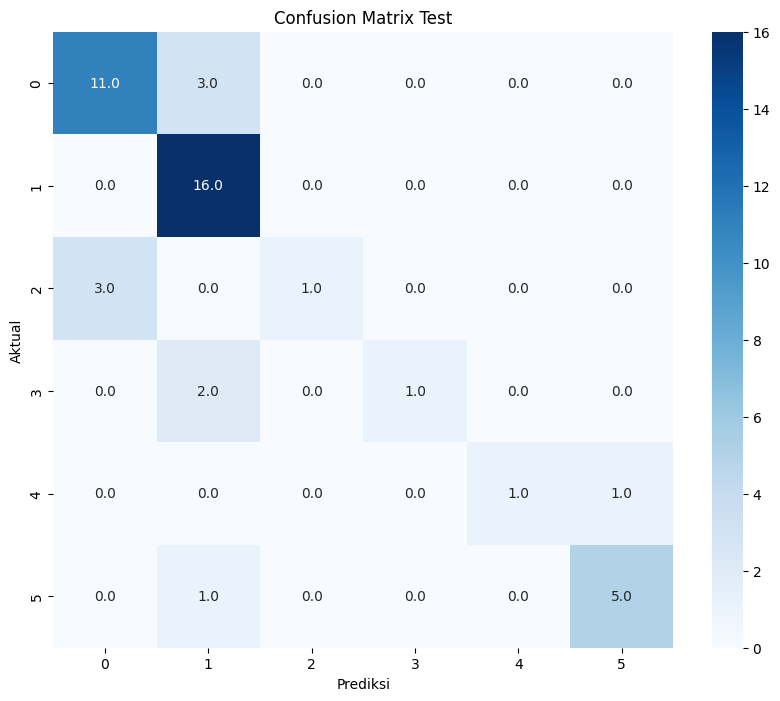

In [42]:
# Inisialisasi Fungsi Confision Matrix terhadap Test

confusion_matrix(y_test, y_pred_test, title='Test')

In [43]:
# Fungsi Visualisasi Poin Kesalahan

def incorrect_point(y_true, y_pred, X, title='Train'):
    incorrect = y_true != y_pred
    correct = ~incorrect

    n_incorrect = np.sum(incorrect)
    n_correct = np.sum(correct)

    plt.figure(figsize=(10,8))
    plt.scatter(X[incorrect, 0], X[incorrect, 1], color='red', label=f'Salah ({n_incorrect})')
    plt.scatter(X[correct, 0], X[correct, 1], color='blue', label=f'Benar ({n_correct})')
    plt.title(f'Point Kesalahan {title}')
    plt.legend()
    plt.grid()
    plt.show()

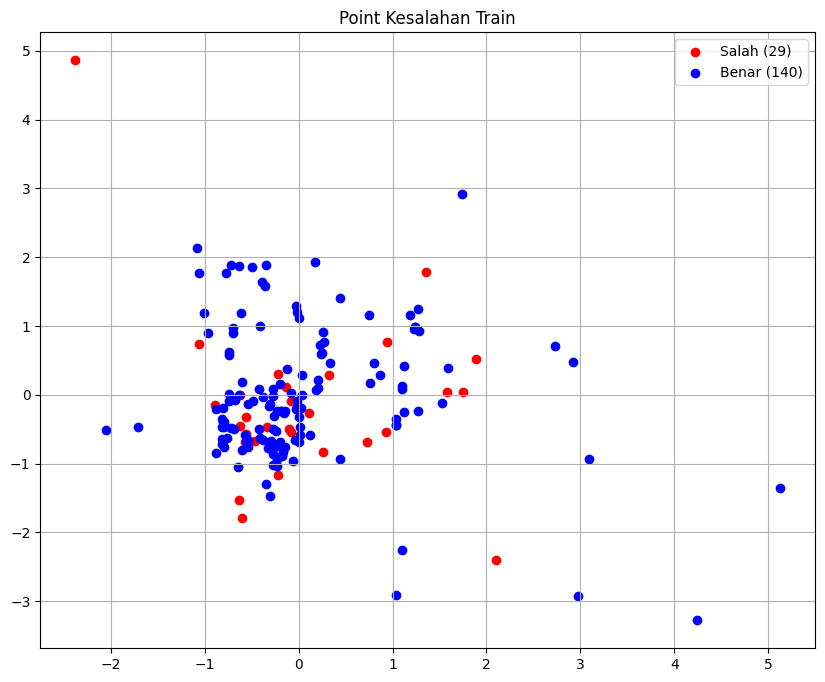

In [44]:
# Inisialisasi Poin Kesalahan terhadap Train

incorrect_point(y_train, y_pred_train, X_train.values)

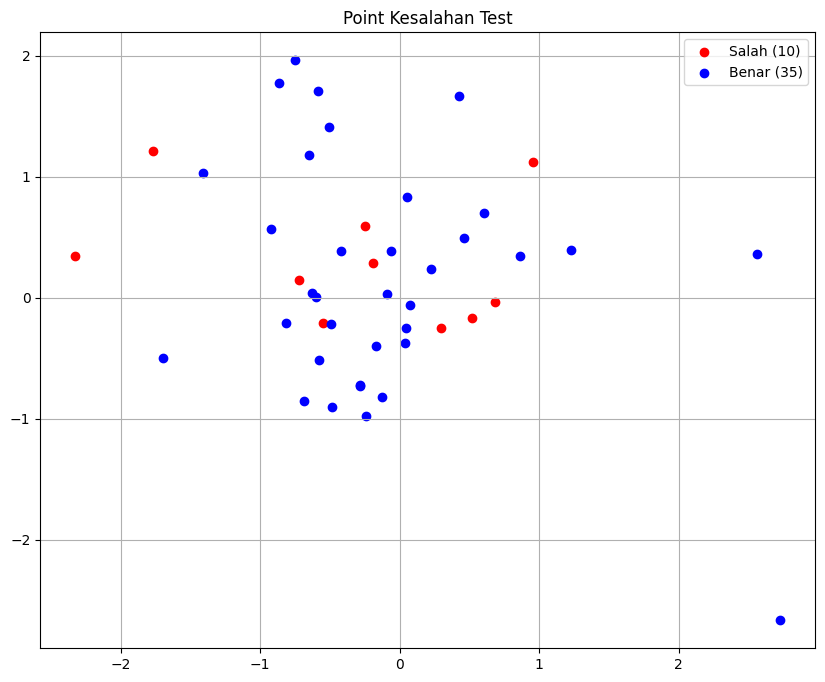

In [45]:
# Inisialisasi Poin Kesalahan terhadap Test

incorrect_point(y_test, y_pred_test, X_test.values, title='Test')

## **GUI**

In [49]:
feature = X.columns
n_feature = len(feature)

def submit():
    try:
        input_data = []
        for entry in entries:
            value = float(entry.get())
            input_data.append(value)
        
        input_df = pd.DataFrame([input_data], columns=feature)
        input_scaled = (input_df - X_before.mean()) / X_before.std()
        prediction = model.predict(input_scaled.values)
        messagebox.showinfo('Hasil Prediksi', f'Tipe Kaca: {prediction[0]}')
    except ValueError:
        messagebox.showerror('Input Error', 'Masukan value yang benar')

root = tk.Tk()
root.title('Prediksi Tipe Kaca')
entries = []

title_label = tk.Label(root, text='Prediksi Tipe Kaca', font=('Arial', 25, 'bold'))
title_label.grid(row=0, column=0, columnspan=2 ,padx=25, pady=10)

for i, col in enumerate(feature):
    label = tk.Label(root, text=f'{col}:')
    label.grid(row=i+1, column=0, padx=20, pady=5, sticky='w')

    entry = tk.Entry(root)
    entry.grid(row=i+1, column=1, padx=20, pady=5)
    entries.append(entry)

submit_button = tk.Button(root, text='Predict', command=submit, bg='#5CB338',font=('Arial', 15, 'bold'))
submit_button.grid(row=n_feature+1, column=0, columnspan=2,pady=20, ipadx=10, ipady=5)

root.mainloop()

In [47]:
glass.sample(5)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
135,1.51789,13.19,3.90,1.30,72.33,0.55,8.44,0.0,0.28,2
64,1.52172,13.48,3.74,0.90,72.01,0.18,9.61,0.0,0.07,1
179,1.51852,14.09,2.19,1.66,72.67,0.00,9.32,0.0,0.00,6
56,1.51215,12.99,3.47,1.12,72.98,0.62,8.35,0.0,0.31,1
153,1.51610,13.42,3.40,1.22,72.69,0.59,8.32,0.0,0.00,3


## **KESIMPULAN**

1. Dataset memmiliki nilai yang cukup bersih tidak ada nilai kategori dan nilai kosong, dataset memiliki cukup banyak outlier yang ditangani agar tidak mengganggu model

2. Model bekerja cukup overfitting tapi untuk target yang imbalance hasilnya cukup bagus dengan selisih sekitar 8%, dengan rata-rata skor akurasi 75% dengan presisi (data benar di prediksi benar) 73% dan recall (data benar di prediksi salah) 81%